In [7]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.stats import norm
from helpers import compute_N
from helpers import *

In [8]:
# Set the constants
T0 = 1.0                      # initial temperature
Tbar = 1.0                    # background temperature
Tw = 1.0                      # wall temperature
m = 1.0                       # mass
k = 1.0                       # Boltzmann constant

# Knudsen and Mach numbers
Kn = 0.1
Ma = 0.316

# Derived parameters
Uw = Ma * np.sqrt(k * Tw / m)          # = 0.316 wall velocity
tau = 2 * Kn / np.sqrt(np.pi / 2)     # ≈ 0.225 relaxation time

# Domain
L = 1.0
Nc = 50
dx = L / Nc                            # = 0.02

# Particles
Np = 250000                            # 5000 per cell

# Timestep from paper equation (100)
dt = 0.5 * L / (Nc * np.sqrt(k * Tw / m))  # = 0.01

# Simulation time
t_end = 10.0                            # 100 tau relaxation times
t = 0
Nsteps = int(t_end // dt) + 1

# NW bandwidth
h = 8 * dx                             # = 0.04

# Grid
x_grid = np.linspace(-L/2 + dx/2, L/2 - dx/2, Nc)

correlated_process = True

In [9]:
def compute_weights_NW(X, x_grid, h):
    diff = (X[None, :] - x_grid[:, None]) / h  # Nc x Np
    W = np.exp(-0.5 * diff**2)
    W /= W.sum(axis=1, keepdims=True)
    return W  # Nc x Np

def compute_cell_moments_NW(M, W, m, k, Tbar, Mbar=None, Ubar=None):
    Nc = W.shape[0]
    if Mbar is not None:
        W_col_sum = W.sum(axis=0)  # Np
        Ubar_at_X = (W.T @ Ubar) / W_col_sum[:, None]  # Np x 3
        M_corrected = M - Mbar + Ubar_at_X
    else:
        M_corrected = M
    
    U = W @ M_corrected             # Nc x 3
    
    T = np.zeros(Nc)
    for c in range(Nc):
        residuals = M_corrected - U[c]
        T[c] = (m / (3*k)) * (W[c] * (residuals**2).sum(axis=1)).sum()
        if Mbar is not None and Tbar is not None: # When using VR
            T[c] += Tbar
    
    return U, T

In [10]:
def evolve_velocity_M(M, mask, U_particle, T_particle, dt, tau, m, k, noise):
    M[mask] = (M[mask] - U_particle) * np.exp(-dt/tau) \
            + U_particle \
            + np.sqrt((k * T_particle / m) * (1 - np.exp(-2*dt/tau)))[:, None] * noise


# Add NiNi
def evolve_velocity_Mbar(Mbar, N, mask, dt, tau, m, k, Tbar, noise, NiNi):
    Mbar[mask] = np.exp(-dt/tau) * Mbar[mask] \
               + dt * N[mask] \
               + np.sqrt(np.maximum((k*Tbar/m) * (1 - np.exp(-2*dt/tau)) - dt**2 * NiNi[mask], 0.0)) * noise
    Mbar[mask] = np.clip(Mbar[mask], -10*np.sqrt(k*Tbar/m), 10*np.sqrt(k*Tbar/m))


In [11]:
def apply_wall_bc(X, M, Mbar, L, Tw, Uw, m, k, Tbar):
    # Left wall
    left_mask = X < -L/2
    if left_mask.any():
        # Reflect particle back to boundary
        X[left_mask] = -L/2
        # Re-sample velocity
        N_left = left_mask.sum()
        r1_left = np.random.uniform(size=N_left)
        r2_left = np.random.uniform(size=N_left)
        r3_left = np.random.uniform(size=N_left)
        M[left_mask, 0] = np.sqrt(-2*k*Tw/m * np.log(r1_left))
        M[left_mask, 1] = np.sqrt(-2*k*Tw/m * np.log(r2_left)) * np.sin(2*np.pi*r3_left) + Uw
        M[left_mask, 2] = np.sqrt(-2*k*Tw/m * np.log(r2_left)) * np.cos(2*np.pi*r3_left)

        Mbar[left_mask, 0] = np.sqrt(-2*k*Tbar/m * np.log(r1_left))
        Mbar[left_mask, 1] = np.sqrt(-2*k*Tbar/m * np.log(r2_left)) * np.sin(2*np.pi*r3_left)
        Mbar[left_mask, 2] = np.sqrt(-2*k*Tbar/m * np.log(r2_left)) * np.cos(2*np.pi*r3_left)
        # same for right wall

    # Right wall
    right_mask = X > L/2
    if right_mask.any():
        X[right_mask] = L/2
        N_right = right_mask.sum()
        r1_right = np.random.uniform(size=N_right)
        r2_right = np.random.uniform(size=N_right)
        r3_right = np.random.uniform(size=N_right)
        M[right_mask, 0] = -np.sqrt(-2*k*Tw/m * np.log(r1_right))
        M[right_mask, 1] = np.sqrt(-2*k*Tw/m * np.log(r2_right)) * np.sin(2*np.pi*r3_right) - Uw
        M[right_mask, 2] = np.sqrt(-2*k*Tw/m * np.log(r2_right)) * np.cos(2*np.pi*r3_right)

        Mbar[right_mask, 0] = -np.sqrt(-2*k*Tbar/m * np.log(r1_right))
        Mbar[right_mask, 1] = np.sqrt(-2*k*Tbar/m * np.log(r2_right)) * np.sin(2*np.pi*r3_right)
        Mbar[right_mask, 2] = np.sqrt(-2*k*Tbar/m * np.log(r2_right)) * np.cos(2*np.pi*r3_right)
        # same for right wall


    return left_mask, right_mask

In [12]:
# Implementation of Algorithm 1 
X = np.random.uniform(low=-L/2, high=L/2, size=Np) 

r1 = np.random.uniform(size=Np) 
r2 = np.random.uniform(size=Np) 
r3 = np.random.uniform(size=Np) 
r4 = np.random.uniform(size=Np) 

M = np.zeros((Np, 3)) 
M[:, 0] = np.sqrt(-2 * k * T0 / m * np.log(r1)) * np.cos(2 * np.pi * r2) 
M[:, 1] = np.sqrt(-2 * k * T0 / m * np.log(r3)) * np.sin(2 * np.pi * r4) 
M[:, 2] = np.sqrt(-2 * k * T0 / m * np.log(r3)) * np.cos(2 * np.pi * r4) 

# Mbar: use same r's for correlation
Mbar = np.zeros((Np, 3)) 

Mbar[:, 0] = np.sqrt(-2 * k * Tbar / m * np.log(r1)) * np.cos(2*np.pi*r2)
Mbar[:, 1] = np.sqrt(-2 * k * Tbar / m * np.log(r3)) * np.sin(2*np.pi*r4)
Mbar[:, 2] = np.sqrt(-2 * k * Tbar / m * np.log(r3)) * np.cos(2*np.pi*r4)

U = np.zeros((Nsteps, Nc, 3)) 
T = np.zeros([Nsteps, Nc]) 

x_grid = np.linspace(-L/2 + dx/2, L/2 - dx/2, Nc)

Ubar = np.zeros((Nc, 3))

W = compute_weights_NW(X, x_grid, h)

if correlated_process:
    #Ubar = W @ Mbar  # compute initial Ubar
    U[0], T[0] = compute_cell_moments_NW(M, W, m, k, Tbar, Mbar, Ubar)
else:
    U[0], T[0] = compute_cell_moments_NW(M, W, m, k, Tbar)




for step in tqdm(range(1, Nsteps)):

    # Evolve X^i 
    X = X + dt * M[:, 0] 
    
    # Apply B.C. 
    left_mask, right_mask = apply_wall_bc(X, M, Mbar, L, Tw, Uw, m, k, Tbar) 
    mask_wall = left_mask | right_mask # particles that just hit wall 
    
    # Compute weights once per step
    W = compute_weights_NW(X, x_grid, h)
    
    # Sort particles 
    if correlated_process:    
        N, NiNi = compute_N(M, Mbar, U[step-1], W, dx, m, k, Tbar, tau)

    # For debugging

        if step in [1, 10, 50, 100, 200, 500, 750]:
            alpha = compute_alpha(M, Mbar, W, dx)
            cbar = compute_cbar(M, Mbar, U[step-1], W, dx, m, k, Tbar, tau)
            
            print(f"\n{'='*50}")
            print(f"Step {step}")
            print(f"{'='*50}")
            
            print(f"\n  N statistics:")
            for d, name in enumerate(['x','y','z']):
                print(f"    N[{name}]: mean={np.mean(N[:,d]):+.4f}  std={np.std(N[:,d]):.4f}  max={np.abs(N[:,d]).max():.4f}")
            
            print(f"\n  Particle statistics:")
            print(f"    std(Mbar[:,0]) = {np.std(Mbar[:,0]):.4f}")
            print(f"    std(M-Mbar)    = {np.std(M[:,0]-Mbar[:,0]):.4f}")
            print(f"    mean(M-Mbar)   = {np.mean(M[:,0]-Mbar[:,0]):.4f}")
            
            print(f"\n  Coefficient statistics:")
            print(f"    alpha: mean={np.mean(alpha):+.4f}  std={np.std(alpha):.4f}  max={np.abs(alpha).max():.4f}")
            print(f"    cbar:  mean={np.mean(cbar):+.4f}  std={np.std(cbar):.4f}  max={np.abs(cbar).max():.4f}")
            print(f"    cbar diagonal only:")
            for d in range(3):
                print(f"      cbar[{d},{d}]: mean={np.mean(cbar[:,d,d]):+.4f}  std={np.std(cbar[:,d,d]):.4f}")
            
            # Energy correction health check
            NiNi = compute_NiNi_analytical(alpha, cbar, 
                   compute_gammabar(alpha, M, Mbar, W, dx, m, k, Tbar),
                   -((m/(2*k*Tbar))**2)/tau, tau, Tbar)
            Atilde = (k*Tbar/m)*(1-np.exp(-2*dt/tau)) - dt**2 * NiNi
            print(f"\n  Energy correction A_tilde:")
            print(f"    min={Atilde.min():.6f}  mean={Atilde.mean():.6f}")
            pct_negative = 100 * np.mean(Atilde < 0)
            print(f"    % negative (clamped to 0): {pct_negative:.1f}%")
            print(f"{'='*50}\n")
    
            print(f"U[step,:,0] (wall-normal, should be ~0):")
            print(U[step-1,:,0])
            print(f"U[step,:,1] (streamwise, should be linear):")  
            print(U[step-1,:,1])

    
    W_col_sum = W.sum(axis=0)  # Nc x Np summed over Nc -> shape (Np,)
    T_at_particle = (W.T @ T[step-1]) / W_col_sum   # Np
    U_at_particle = (W.T @ U[step-1]) / W_col_sum[:, None]  # Np x 3

    mask_update = ~mask_wall # exclude wall-hitting particles, because they are already handled  
    
    # Evolve V^i
    noise = np.random.normal(0,1,size=M[mask_update].shape) # Common noise
    evolve_velocity_M(M, mask_update, U_at_particle[mask_update], T_at_particle[mask_update], dt, tau, m, k, noise)

    
    
    if correlated_process:
        # Interpolate to particles
        W_col_sum = W.sum(axis=0)
        NiNi_at_particle = (W.T @ NiNi) / W_col_sum[:, None]  # Np x 3
        #evolve_velocity_Mbar(Mbar, N, mask_update, dt, tau, m, k, Tbar, noise) 
        evolve_velocity_Mbar(Mbar, N, mask_update, dt, tau, m, k, Tbar, noise, NiNi_at_particle)
        
        #Ubar = W @ Mbar 
        U[step], T[step] = compute_cell_moments_NW(M, W, m, k, Tbar, Mbar, Ubar)
    else:
        U[step], T[step] = compute_cell_moments_NW(M, W, m, k, Tbar)

  0%|                                                   | 0/999 [00:00<?, ?it/s]


Step 1

  N statistics:
    N[x]: mean=-0.0010  std=16.4214  max=84.4252
    N[y]: mean=-0.0493  std=16.4025  max=57.2771
    N[z]: mean=+0.0256  std=16.4456  max=67.8050

  Particle statistics:
    std(Mbar[:,0]) = 1.0000
    std(M-Mbar)    = 0.0000
    mean(M-Mbar)   = 0.0000

  Coefficient statistics:
    alpha: mean=+0.0000  std=0.0000  max=0.0000
    cbar:  mean=+5.7444  std=8.1237  max=17.2331
    cbar diagonal only:
      cbar[0,0]: mean=+17.2331  std=0.0000
      cbar[1,1]: mean=+17.2331  std=0.0000
      cbar[2,2]: mean=+17.2331  std=0.0000

  Energy correction A_tilde:
    min=0.090797  mean=0.090797
    % negative (clamped to 0): 0.0%

U[step,:,0] (wall-normal, should be ~0):
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
U[step,:,1] (streamwise, should be linear):
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0

  1%|▎                                          | 6/999 [00:03<08:24,  1.97it/s]


Step 10

  N statistics:
    N[x]: mean=+0.0065  std=13.6764  max=61.6693
    N[y]: mean=-0.0006  std=14.0041  max=60.9798
    N[z]: mean=+0.0278  std=14.0178  max=55.2986

  Particle statistics:
    std(Mbar[:,0]) = 1.7513
    std(M-Mbar)    = 1.0503
    mean(M-Mbar)   = 0.0003

  Coefficient statistics:
    alpha: mean=+0.0058  std=0.2462  max=0.6796
    cbar:  mean=+5.5295  std=7.8182  max=16.8498
    cbar diagonal only:
      cbar[0,0]: mean=+16.2597  std=0.0812
      cbar[1,1]: mean=+16.7451  std=0.0450
      cbar[2,2]: mean=+16.7486  std=0.0432

  Energy correction A_tilde:
    min=0.091984  mean=0.092763
    % negative (clamped to 0): 0.0%

U[step,:,0] (wall-normal, should be ~0):
[ 0.12082508  0.11644344  0.11195207  0.10735683  0.10266429  0.09788157
  0.09301618  0.08807584  0.0830683   0.07800116  0.07288172  0.06771699
  0.06251359  0.0572779   0.05201621  0.04673492  0.04144084  0.03614135
  0.03084466  0.02555983  0.02029672  0.01506577  0.00987759  0.00474244
 -0.000330

  5%|██                                        | 49/999 [00:25<08:47,  1.80it/s]

...

 50%|████████████████████▍                    | 499/999 [05:01<04:26,  1.87it/s]


Step 500

  N statistics:
    N[x]: mean=-0.1487  std=14.9184  max=57.0842
    N[y]: mean=-0.1476  std=13.7943  max=68.7773
    N[z]: mean=+0.1170  std=13.7853  max=56.3853

  Particle statistics:
    std(Mbar[:,0]) = 2.0061
    std(M-Mbar)    = 1.7326
    mean(M-Mbar)   = 0.0022

  Coefficient statistics:
    alpha: mean=-0.0029  std=0.3669  max=1.1551
    cbar:  mean=+6.2784  std=8.8853  max=19.4369
    cbar diagonal only:
      cbar[0,0]: mean=+18.5059  std=0.3330
      cbar[1,1]: mean=+19.0071  std=0.2934
      cbar[2,2]: mean=+19.0071  std=0.2945

  Energy correction A_tilde:
    min=0.083401  mean=0.085399
    % negative (clamped to 0): 0.0%

U[step,:,0] (wall-normal, should be ~0):
[-0.4195003  -0.40749298 -0.39442303 -0.38027209 -0.36503839 -0.3487406
 -0.33142162 -0.31315186 -0.29403172 -0.27419267 -0.25379637 -0.23303141
 -0.21210727 -0.19124561 -0.17066901 -0.15058812 -0.13118806 -0.11261561
 -0.09496833 -0.07828698 -0.06255186 -0.04768349 -0.03354753 -0.01996329
 -0.006715

 75%|██████████████████████████████▋          | 749/999 [07:16<02:11,  1.90it/s]


Step 750

  N statistics:
    N[x]: mean=+0.1598  std=14.8364  max=74.9923
    N[y]: mean=-0.0415  std=13.8049  max=65.3327
    N[z]: mean=+0.2039  std=13.7969  max=54.7802

  Particle statistics:
    std(Mbar[:,0]) = 2.0023
    std(M-Mbar)    = 1.7342
    mean(M-Mbar)   = 0.0088

  Coefficient statistics:
    alpha: mean=+0.0115  std=0.3720  max=1.2015
    cbar:  mean=+6.2731  std=8.8718  max=19.3817
    cbar diagonal only:
      cbar[0,0]: mean=+18.4781  std=0.3003
      cbar[1,1]: mean=+18.9942  std=0.2853
      cbar[2,2]: mean=+18.9752  std=0.2730

  Energy correction A_tilde:
    min=0.083596  mean=0.085486
    % negative (clamped to 0): 0.0%

U[step,:,0] (wall-normal, should be ~0):
[-0.41455677 -0.40202017 -0.38842486 -0.37376364 -0.35804716 -0.34130721
 -0.32359983 -0.30500764 -0.28564116 -0.26563862 -0.24516387 -0.22440205
 -0.20355297 -0.1828223  -0.16241121 -0.14250494 -0.12326167 -0.10480242
 -0.08720323 -0.07049021 -0.05463797 -0.03957141 -0.02517047 -0.01127749
  0.00229

100%|█████████████████████████████████████████| 999/999 [09:25<00:00,  1.77it/s]


In [13]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

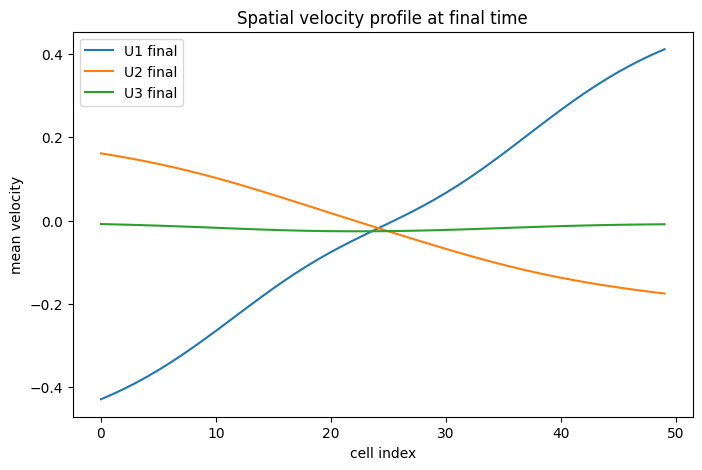

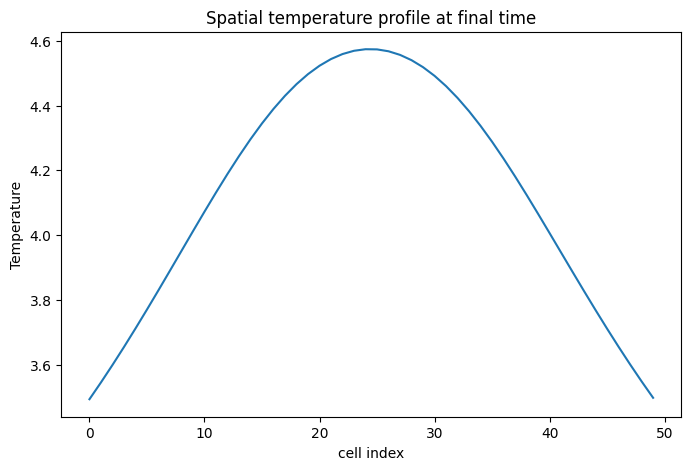

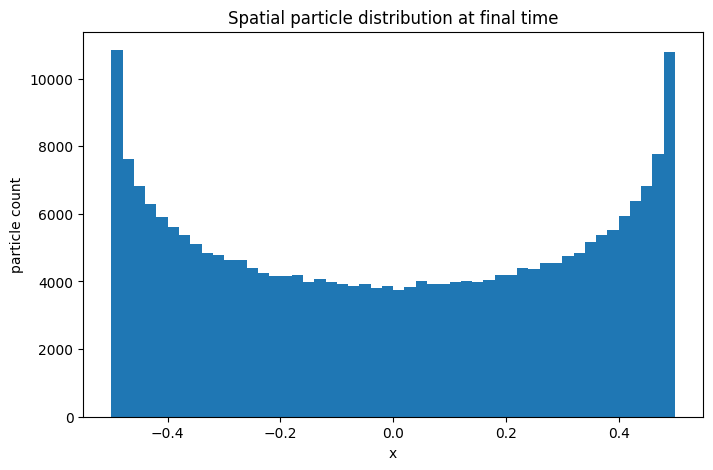

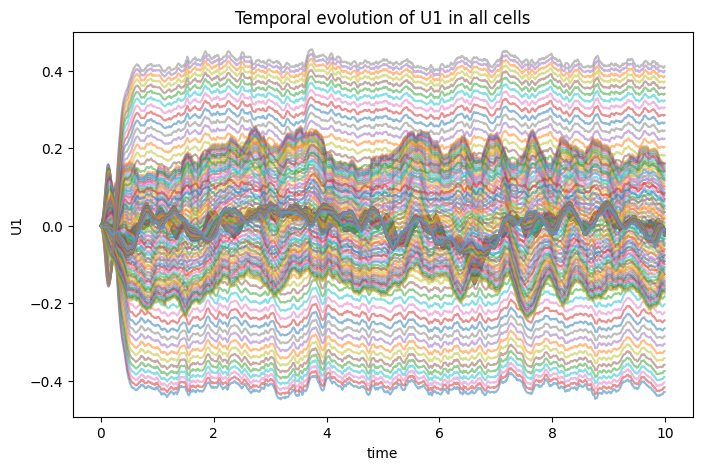

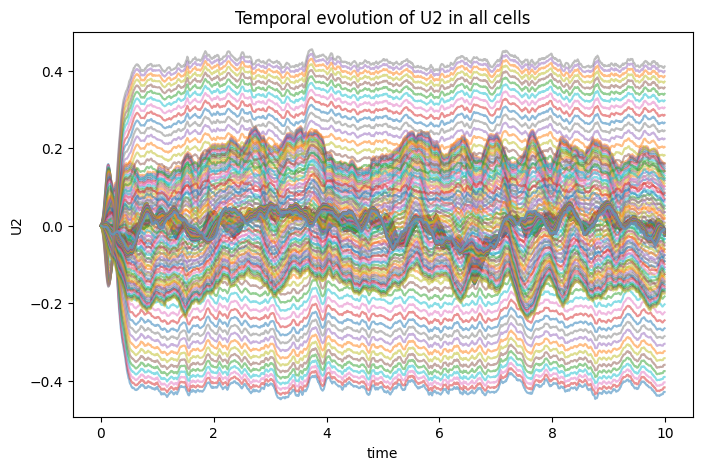

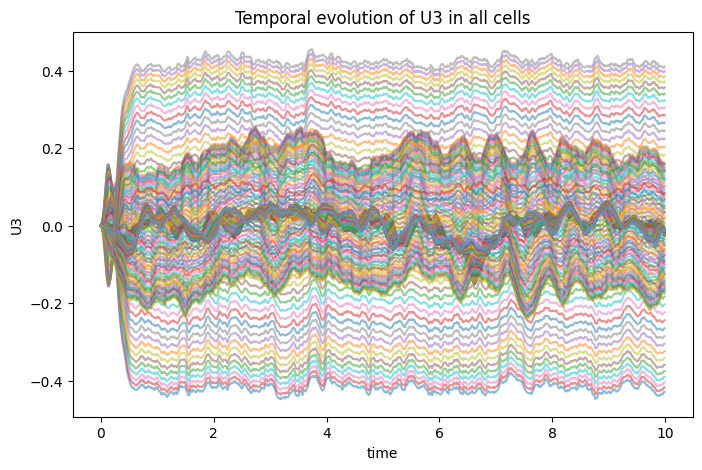

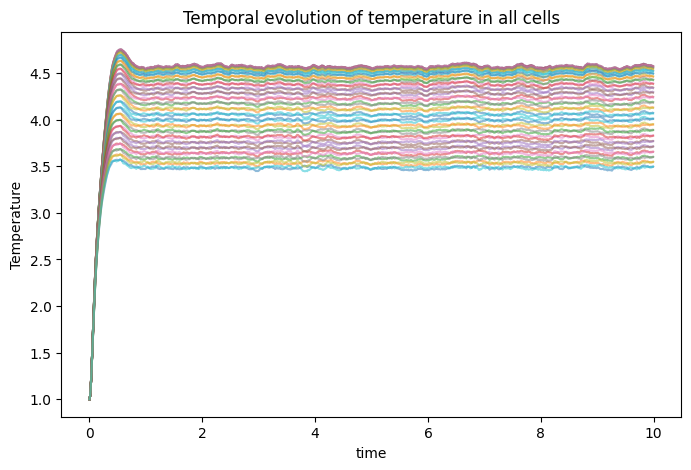

In [14]:
plt.figure(figsize=(8,5))
plt.plot(range(Nc), U[-1,:, 0], label='U1 final')
plt.plot(range(Nc), U[-1,:, 1], label='U2 final')
plt.plot(range(Nc), U[-1,:, 2], label='U3 final')
plt.legend()
plt.xlabel('cell index')
plt.ylabel('mean velocity')
plt.title('Spatial velocity profile at final time')
plt.show()
plt.figure(figsize=(8,5))
plt.plot(range(Nc), T[-1,:])
plt.xlabel('cell index')
plt.ylabel('Temperature')
plt.title('Spatial temperature profile at final time')
plt.show()
plt.figure(figsize=(8,5))
plt.hist(X, bins=Nc)
plt.xlabel('x')
plt.ylabel('particle count')
plt.title('Spatial particle distribution at final time')
plt.show()
plt.figure(figsize=(8,5))
for c in range(Nc):
    plt.plot(np.arange(Nsteps)*dt, U[:,c], alpha=0.5)
plt.xlabel('time')
plt.ylabel('U1')
plt.title('Temporal evolution of U1 in all cells')
plt.show()
plt.figure(figsize=(8,5))
for c in range(Nc):
    plt.plot(np.arange(Nsteps)*dt, U[:,c], alpha=0.5)
plt.xlabel('time')
plt.ylabel('U2')
plt.title('Temporal evolution of U2 in all cells')
plt.show()
plt.figure(figsize=(8,5))
for c in range(Nc):
    plt.plot(np.arange(Nsteps)*dt, U[:,c], alpha=0.5)
plt.xlabel('time')
plt.ylabel('U3')
plt.title('Temporal evolution of U3 in all cells')
plt.show()
plt.figure(figsize=(8,5))
for c in range(Nc):
    plt.plot(np.arange(Nsteps)*dt, T[:,c], alpha=0.5)
plt.xlabel('time')
plt.ylabel('Temperature')
plt.title('Temporal evolution of temperature in all cells')
plt.show()

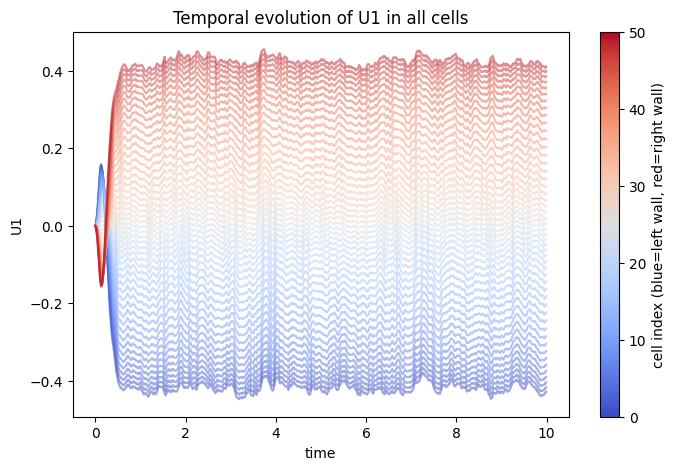

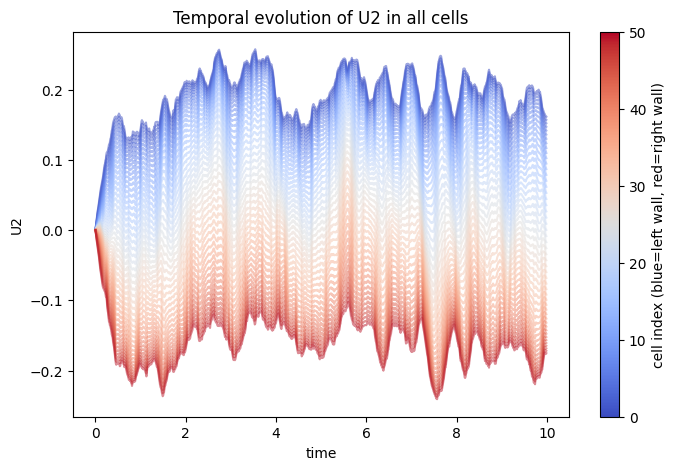

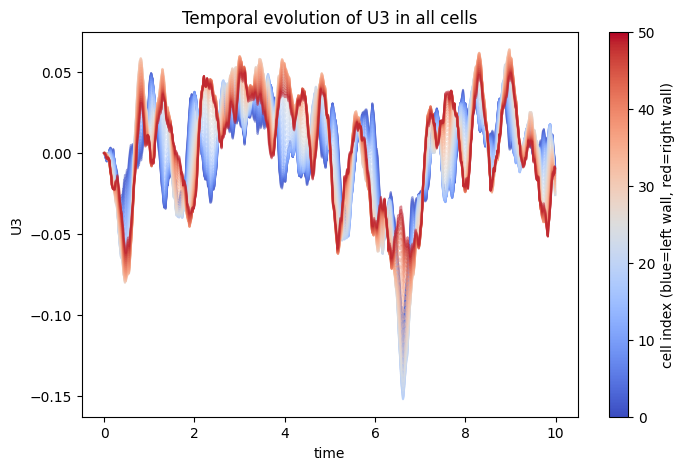

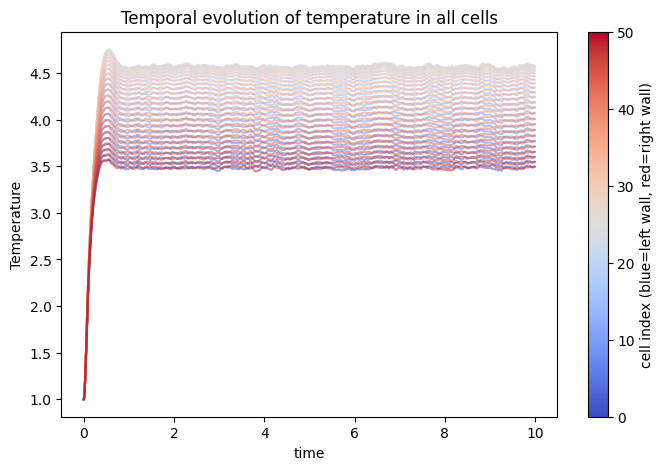

In [15]:
# Temporal U1
fig, ax = plt.subplots(figsize=(8,5))
for c in range(Nc):
    ax.plot(np.arange(Nsteps)*dt, U[:,c,0], alpha=0.5,
            color=plt.cm.coolwarm(c/Nc))
sm = ScalarMappable(cmap='coolwarm', norm=Normalize(vmin=0, vmax=Nc))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='cell index (blue=left wall, red=right wall)')
ax.set_xlabel('time')
ax.set_ylabel('U1')
ax.set_title('Temporal evolution of U1 in all cells')
plt.show()

# Temporal U2
fig, ax = plt.subplots(figsize=(8,5))
for c in range(Nc):
    ax.plot(np.arange(Nsteps)*dt, U[:,c,1], alpha=0.5,
            color=plt.cm.coolwarm(c/Nc))
sm = ScalarMappable(cmap='coolwarm', norm=Normalize(vmin=0, vmax=Nc))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='cell index (blue=left wall, red=right wall)')
ax.set_xlabel('time')
ax.set_ylabel('U2')
ax.set_title('Temporal evolution of U2 in all cells')
plt.show()

# Temporal U3
fig, ax = plt.subplots(figsize=(8,5))
for c in range(Nc):
    ax.plot(np.arange(Nsteps)*dt, U[:,c,2], alpha=0.5,
            color=plt.cm.coolwarm(c/Nc))
sm = ScalarMappable(cmap='coolwarm', norm=Normalize(vmin=0, vmax=Nc))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='cell index (blue=left wall, red=right wall)')
ax.set_xlabel('time')
ax.set_ylabel('U3')
ax.set_title('Temporal evolution of U3 in all cells')
plt.show()

# Temporal temperature
fig, ax = plt.subplots(figsize=(8,5))
for c in range(Nc):
    ax.plot(np.arange(Nsteps)*dt, T[:,c], alpha=0.5,
            color=plt.cm.coolwarm(c/Nc))
sm = ScalarMappable(cmap='coolwarm', norm=Normalize(vmin=0, vmax=Nc))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='cell index (blue=left wall, red=right wall)')
ax.set_xlabel('time')
ax.set_ylabel('Temperature')
ax.set_title('Temporal evolution of temperature in all cells')
plt.show()

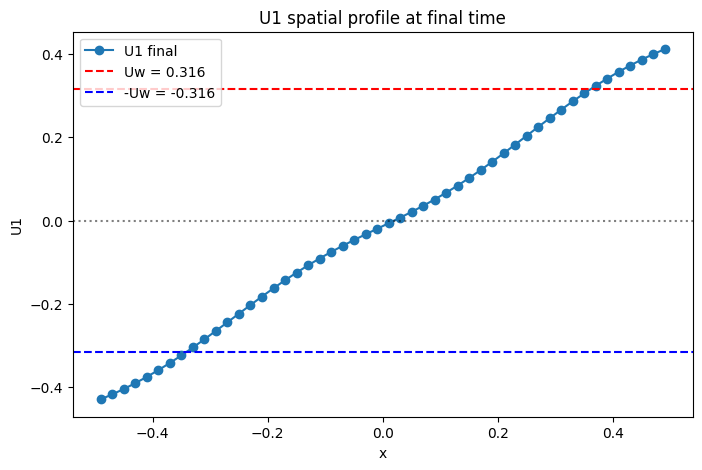

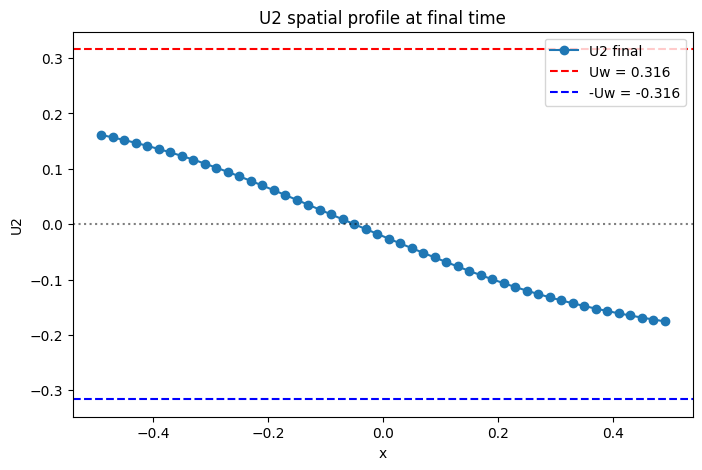

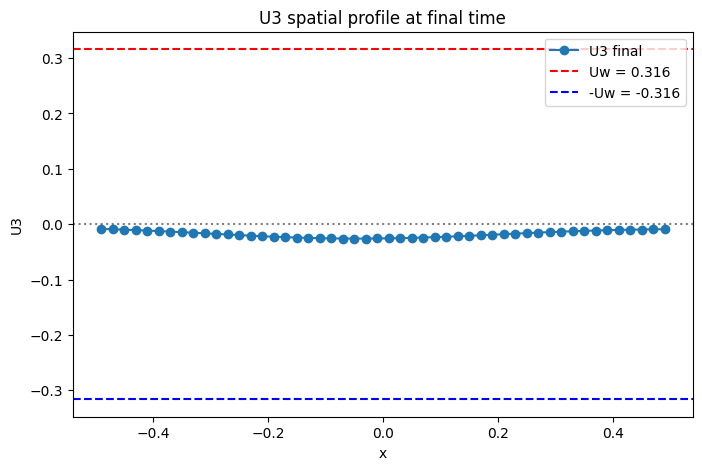

In [16]:
plt.figure(figsize=(8,5))
plt.plot(x_grid, U[-1, :, 0], 'o-', label='U1 final')
plt.axhline(y=Uw, color='r', linestyle='--', label=f'Uw = {Uw}')
plt.axhline(y=-Uw, color='b', linestyle='--', label=f'-Uw = {-Uw}')
plt.axhline(y=0, color='k', linestyle=':', alpha=0.5)
plt.xlabel('x')
plt.ylabel('U1')
plt.title('U1 spatial profile at final time')
plt.legend()
plt.show()


plt.figure(figsize=(8,5))
plt.plot(x_grid, U[-1, :, 1], 'o-', label='U2 final')
plt.axhline(y=Uw, color='r', linestyle='--', label=f'Uw = {Uw}')
plt.axhline(y=-Uw, color='b', linestyle='--', label=f'-Uw = {-Uw}')
plt.axhline(y=0, color='k', linestyle=':', alpha=0.5)
plt.xlabel('x')
plt.ylabel('U2')
plt.title('U2 spatial profile at final time')
plt.legend()
plt.show()


plt.figure(figsize=(8,5))
plt.plot(x_grid, U[-1, :, 2], 'o-', label='U3 final')
plt.axhline(y=Uw, color='r', linestyle='--', label=f'Uw = {Uw}')
plt.axhline(y=-Uw, color='b', linestyle='--', label=f'-Uw = {-Uw}')
plt.axhline(y=0, color='k', linestyle=':', alpha=0.5)
plt.xlabel('x')
plt.ylabel('U3')
plt.title('U3 spatial profile at final time')
plt.legend()
plt.show()

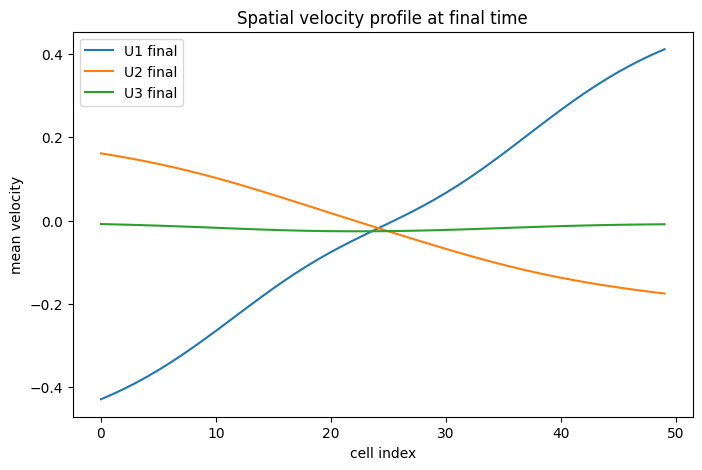

In [17]:
plt.figure(figsize=(8,5))
plt.plot(range(Nc), U[-1,:, 0], label='U1 final')
plt.plot(range(Nc), U[-1,:, 1], label='U2 final')
plt.plot(range(Nc), U[-1,:, 2], label='U3 final')
plt.legend()
plt.xlabel('cell index')
plt.ylabel('mean velocity')
plt.title('Spatial velocity profile at final time')
plt.show()

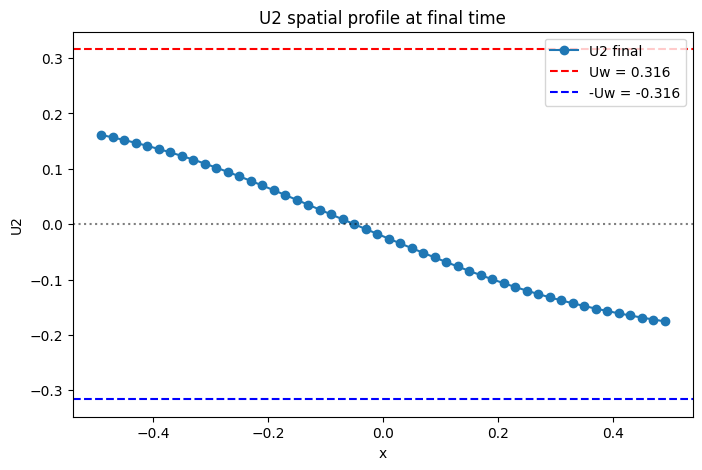

In [18]:
plt.figure(figsize=(8,5))
plt.plot(x_grid, U[-1, :, 1], 'o-', label='U2 final')
plt.axhline(y=Uw, color='r', linestyle='--', label=f'Uw = {Uw}')
plt.axhline(y=-Uw, color='b', linestyle='--', label=f'-Uw = {-Uw}')
plt.axhline(y=0, color='k', linestyle=':', alpha=0.5)
plt.xlabel('x')
plt.ylabel('U2')
plt.title('U2 spatial profile at final time')
plt.legend()
plt.show()

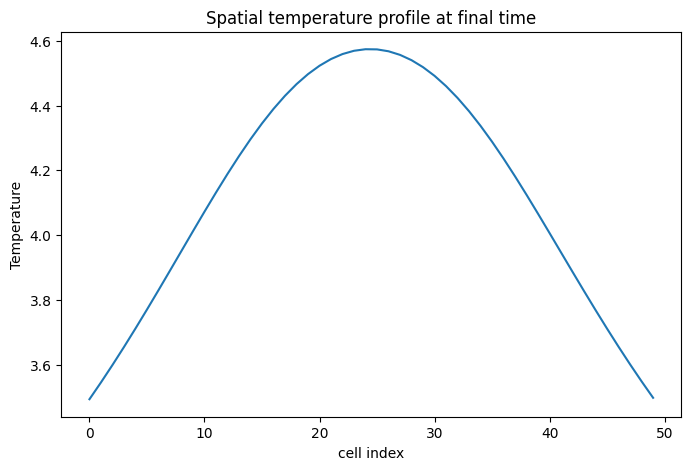

In [19]:
plt.figure(figsize=(8,5))
plt.plot(range(Nc), T[-1,:])
plt.xlabel('cell index')
plt.ylabel('Temperature')
plt.title('Spatial temperature profile at final time')
plt.show()

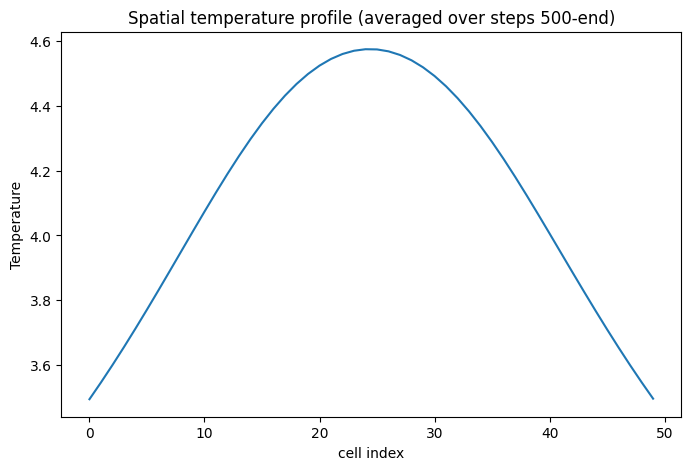

In [20]:
T_avg = np.mean(T[-2:, :], axis=0)  
plt.figure(figsize=(8,5))
plt.plot(range(Nc), T_avg)  
plt.xlabel('cell index')
plt.ylabel('Temperature')
plt.title('Spatial temperature profile (averaged over steps 500-end)')
plt.show()

NameError: name 'mu' is not defined

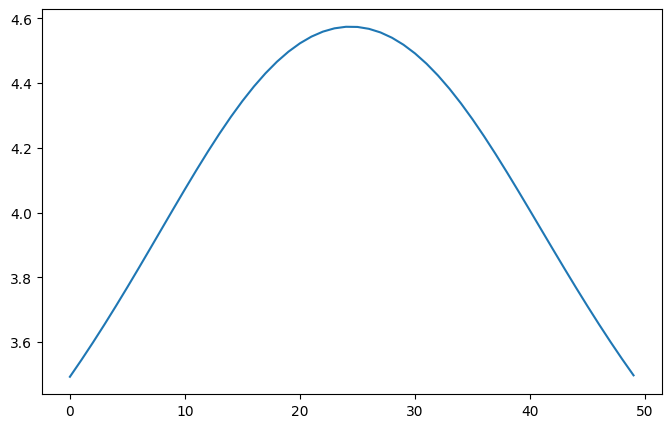

In [21]:
plt.figure(figsize=(8,5))
plt.plot(range(Nc), T[-1,:], label='FP simulation')

# Analytical parabolic profile for Couette flow with linear FP (Pr = 3/2)
x = np.linspace(-L/2, L/2, Nc)

T_analytical = Tw + (3/2) * mu * (Uw/L)**2 / (k/m) * (L**2/4 - x**2)

plt.plot(range(Nc), T_analytical, 'r--', label=f'Analytical (Pr=3/2)')
plt.xlabel('cell index')
plt.ylabel('Temperature')
plt.title('Spatial temperature profile at final time')
plt.legend()
plt.show()

print(f"T center analytical: {T_analytical[Nc//2]:.4f}")
print(f"T center simulation: {T[-1, Nc//2]:.4f}")
print(f"T wall   analytical: {T_analytical[0]:.4f}")
print(f"T wall   simulation: {T[-1, 0]:.4f}")

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(x_grid, T[-1,:], label='FP simulation')

# Analytical parabolic profile for Couette flow with linear FP (Pr = 3/2)
mu = k * Tw / m * tau / 2  # dynamic viscosity
T_analytical = Tw + (3/2) * mu * (Uw/L)**2 / (k/m) * (L**2/4 - x_grid**2)

plt.plot(x_grid, T_analytical, 'r--', label='Analytical (Pr=3/2)')
plt.xlabel('x')
plt.ylabel('Temperature')
plt.title('Spatial temperature profile at final time')
plt.legend()
plt.show()

print(f"T center analytical: {T_analytical[Nc//2]:.4f}")
print(f"T center simulation: {T[-1, Nc//2]:.4f}")
print(f"T wall   analytical: {T_analytical[0]:.4f}")
print(f"T wall   simulation: {T[-1, 0]:.4f}")

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(x_grid, T[-1,:], label='FP simulation')

mu = k * Tw / m * tau / 2
T_analytical = Tw + (3/2) * mu * (Uw/L)**2 / (k/m) * (L**2/4 - x_grid**2)

plt.plot(x_grid, T_analytical, 'r--', label='Analytical (Pr=3/2)')
plt.axhline(y=Tw, color='k', linestyle=':', alpha=0.5, label=f'Tw = {Tw}')
plt.xlabel('x')
plt.ylabel('Temperature')
plt.title('Spatial temperature profile at final time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Correct analytical parabola for Couette flow
# Pr = 3/2 for linear FP
Pr = 3/2
T_analytical = (Tw + (Pr / 2) * (m * Uw**2 / (2 * k)) * (1 - 4 * x_grid**2 / L**2)) * 4

plt.figure(figsize=(8,5))
plt.plot(x_grid, T[-1,:], label='FP simulation')
plt.plot(x_grid, T_analytical, 'r--', label='Analytical (Pr=3/2)')
plt.axhline(y=Tw, color='k', linestyle=':', alpha=0.5, label=f'Tw = {Tw}')
plt.xlabel('x')
plt.ylabel('Temperature')
plt.title('Spatial temperature profile at final time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"T center analytical: {T_analytical[Nc//2]:.6f}")
print(f"T wall   analytical: {T_analytical[0]:.6f}")
print(f"Delta T  analytical: {T_analytical[Nc//2] - Tw:.6f}")